## imports

In [4]:
import os
import copy
import math
import yaml
import json
import logging
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field, asdict
import dataclasses

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from ultralytics import YOLO

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# to reproduce results
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device : cpu
PyTorch : 2.11.0+cpu


## config

In [36]:
@dataclass
class LoRAConfig:
    """LoRA hyperparameters"""
    rank: int = 8 # rang r des matrices A, B
    alpha: float = 16.0 # scaling : ΔW = (alpha/rank) · A·B
    dropout: float = 0.05 # dropout sur la sortie LoRA
    target_modules: List[str] = field( # modules à adapter (regex-like)
        default_factory=lambda: ["Conv2d", "Linear"]
    )
    min_weight_size: int = 16 # ignorer les couches trop petites


@dataclass
class TrainingConfig:
    """Training hyperparameters."""
    epochs: int = 30
    batch_size: int = 8
    lr: float = 1e-3 # LR plus élevé : on n'entraîne que LoRA
    weight_decay: float = 1e-2
    warmup_epochs: int = 3
    grad_clip: float = 1.0
    save_dir: str = "./checkpoints"
    img_size: int = 640


@dataclass
class InsectConfig:
    """insect group config"""
    # pointing to YOLO dataset
    groups: Dict[str, str] = field(default_factory=lambda: {
        "lepidoptera": "../datasets/Lepidoptera",
        "hymenoptera": "../datasets/Hymenoptera",
        "coleoptera": "../datasets/Coleoptera"
    })
    
    num_keypoints: int = 42
    base_model: str = "yolo26n-pose.pt" 

lora_cfg = LoRAConfig()
train_cfg = TrainingConfig()
insect_cfg = InsectConfig()

print("Configuration LoRA :")
print(json.dumps(asdict(lora_cfg), indent=2))
print("\nGroupes d'insectes :")
for grp in insect_cfg.groups:
    print(f"  • {grp}")

Configuration LoRA :
{
  "rank": 8,
  "alpha": 16.0,
  "dropout": 0.05,
  "target_modules": [
    "Conv2d",
    "Linear"
  ],
  "min_weight_size": 16
}

Groupes d'insectes :
  • lepidoptera
  • hymenoptera
  • coleoptera


## LoRA


Pour une couche de poids $W_0 \in \mathbb{R}^{d_{out} \times d_{in}}$, on remplace la mise à jour par :

$$h = W_0 x + \underbrace{\frac{\alpha}{r} \cdot BA}_{\Delta W} x$$

avec $A \in \mathbb{R}^{r \times d_{in}}$, $B \in \mathbb{R}^{d_{out} \times r}$, $r \ll \min(d_{in}, d_{out})$.

In [37]:
class LoRALinear(nn.Module):
    """
    Adaptateur LoRA pour nn.Linear.
    Le poids original W_base est gelé ; seuls A et B sont entraînés.
    """

    def __init__(
        self,
        base_layer: nn.Linear,
        rank: int,
        alpha: float,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.base_layer = base_layer
        # Geler le poids de base
        for p in self.base_layer.parameters():
            p.requires_grad = False

        in_features  = base_layer.in_features
        out_features = base_layer.out_features
        self.rank    = rank
        self.scaling = alpha / rank

        # Matrices basse-rang
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        self.dropout = nn.Dropout(dropout)

        # Initialisation : A ~ N(0, 1/√rank), B = 0 → ΔW = 0 au départ
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.base_layer(x)
        lora_out = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        return base_out + self.scaling * lora_out

    def extra_repr(self) -> str:
        return (f"rank={self.rank}, scaling={self.scaling:.3f}, "
                f"in={self.base_layer.in_features}, out={self.base_layer.out_features}")


class LoRAConv2d(nn.Module):
    """
    Adaptateur LoRA pour nn.Conv2d.
    Implémenté comme deux convolutions séquentielles de rang réduit :
      Conv(in, r, 1) → Conv(r, out, k, padding)
    """

    def __init__(
        self,
        base_layer: nn.Conv2d,
        rank: int,
        alpha: float,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.base_layer = base_layer
        for p in self.base_layer.parameters():
            p.requires_grad = False

        in_ch  = base_layer.in_channels
        out_ch = base_layer.out_channels
        k      = base_layer.kernel_size
        pad    = base_layer.padding
        stride = base_layer.stride

        self.rank    = rank
        self.scaling = alpha / rank

        # Décomposition : Conv(in, r, 1) puis Conv(r, out, k)
        self.lora_down = nn.Conv2d(in_ch, rank, 1, bias=False)
        self.lora_up   = nn.Conv2d(rank, out_ch, k,
                                   padding=pad, stride=stride, bias=False)
        self.dropout   = nn.Dropout2d(dropout)

        nn.init.kaiming_uniform_(self.lora_down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_up.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.base_layer(x) + self.scaling * self.lora_up(self.lora_down(self.dropout(x)))

    def extra_repr(self) -> str:
        return (f"rank={self.rank}, scaling={self.scaling:.3f}, "
                f"in_ch={self.base_layer.in_channels}, out_ch={self.base_layer.out_channels}")


print("✓ LoRALinear et LoRAConv2d définis")

✓ LoRALinear et LoRAConv2d définis


### 2.2 Injection des adaptateurs dans le modèle

In [38]:
class LoRAInjector:
    """
    Parcourt récursivement le modèle et remplace les couches cibles
    par leurs équivalents LoRA.
    """

    def __init__(self, config: LoRAConfig):
        self.config = config
        self._injected: List[str] = []
        self._skipped:  List[str] = []

    def inject(self, model: nn.Module) -> nn.Module:
        """Injecte LoRA dans `model` (in-place) et retourne le modèle."""
        self._replace_recursive(model, prefix="")
        logger.info(
            f"LoRA injecté dans {len(self._injected)} couches, "
            f"{len(self._skipped)} ignorées (trop petites)."
        )
        return model

    def _should_replace(self, module: nn.Module, name: str) -> bool:
        module_type = type(module).__name__
        if module_type not in self.config.target_modules:
            return False
        if isinstance(module, nn.Linear):
            return min(module.in_features, module.out_features) >= self.config.min_weight_size
        if isinstance(module, nn.Conv2d):
            return min(module.in_channels, module.out_channels) >= self.config.min_weight_size
        return False

    def _replace_recursive(self, module: nn.Module, prefix: str):
        for child_name, child_module in list(module.named_children()):
            full_name = f"{prefix}.{child_name}" if prefix else child_name
            if self._should_replace(child_module, full_name):
                lora_layer = self._wrap(child_module)
                setattr(module, child_name, lora_layer)
                self._injected.append(full_name)
            else:
                self._replace_recursive(child_module, full_name)

    def _wrap(self, module: nn.Module) -> nn.Module:
        cfg = self.config
        if isinstance(module, nn.Linear):
            return LoRALinear(module, cfg.rank, cfg.alpha, cfg.dropout)
        if isinstance(module, nn.Conv2d):
            return LoRAConv2d(module, cfg.rank, cfg.alpha, cfg.dropout)
        raise TypeError(f"Type non supporté : {type(module)}")

    @property
    def injected_layers(self) -> List[str]:
        return self._injected


def freeze_base_model(model: nn.Module) -> int:
    """Gèle tous les paramètres sauf ceux des adaptateurs LoRA."""
    frozen = 0
    for name, param in model.named_parameters():
        if "lora_A" in name or "lora_B" in name or "lora_down" in name or "lora_up" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
            frozen += param.numel()
    return frozen


def count_parameters(model: nn.Module) -> Dict[str, int]:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable, "frozen": total - trainable}


print("✓ LoRAInjector défini")

✓ LoRAInjector défini


### 2.3 Gestionnaire des poids LoRA par groupe

In [39]:
class LoRAWeightManager:
    """
    Gère la sauvegarde, le chargement et l'échange des poids LoRA
    entre les différents groupes d'insectes.

    Seuls les tenseurs lora_A / lora_B / lora_down / lora_up sont
    stockés pour chaque groupe → stockage minimal.
    """

    LORA_KEYS = ("lora_A", "lora_B", "lora_down.weight", "lora_up.weight")

    def __init__(self, save_dir: str):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self._cache: Dict[str, Dict[str, torch.Tensor]] = {}

    # ── Extraction ────────────────────────────────────────────────────────────
    @staticmethod
    def extract_lora_state(model: nn.Module) -> Dict[str, torch.Tensor]:
        """Extrait uniquement les paramètres LoRA du state_dict."""
        return {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
            if any(key in k for key in LoRAWeightManager.LORA_KEYS)
        }

    # ── Application ───────────────────────────────────────────────────────────
    @staticmethod
    def apply_lora_state(model: nn.Module, lora_state: Dict[str, torch.Tensor]):
        """Charge des poids LoRA dans le modèle (les poids de base restent inchangés)."""
        current_state = model.state_dict()
        current_state.update(lora_state)
        model.load_state_dict(current_state, strict=False)

    # ── Sauvegarde ────────────────────────────────────────────────────────────
    def save_group(self, group_name: str, model: nn.Module, metadata: Optional[dict] = None):
        """Sauvegarde les poids LoRA d'un groupe sur disque."""
        lora_state = self.extract_lora_state(model)
        checkpoint = {
            "group": group_name,
            "lora_state": lora_state,
            "metadata": metadata or {},
            "param_count": sum(v.numel() for v in lora_state.values()),
        }
        path = self.save_dir / f"lora_{group_name}.pt"
        torch.save(checkpoint, path)
        self._cache[group_name] = lora_state
        logger.info(f"  → Groupe '{group_name}' sauvegardé : {path} "
                    f"({checkpoint['param_count']:,} params LoRA)")
        return path

    # ── Chargement ────────────────────────────────────────────────────────────
    def load_group(self, group_name: str, model: nn.Module) -> dict:
        """Charge et applique les poids LoRA d'un groupe."""
        if group_name in self._cache:
            self.apply_lora_state(model, self._cache[group_name])
            return {"source": "cache"}

        path = self.save_dir / f"lora_{group_name}.pt"
        if not path.exists():
            raise FileNotFoundError(f"Pas de checkpoint pour le groupe '{group_name}' : {path}")
        checkpoint = torch.load(path, map_location=DEVICE)
        self.apply_lora_state(model, checkpoint["lora_state"])
        self._cache[group_name] = checkpoint["lora_state"]
        logger.info(f"  ← Groupe '{group_name}' chargé depuis {path}")
        return checkpoint.get("metadata", {})

    # ── Résumé ────────────────────────────────────────────────────────────────
    def summary(self):
        """Affiche un tableau des groupes disponibles sur disque."""
        files = list(self.save_dir.glob("lora_*.pt"))
        if not files:
            print("Aucun groupe sauvegardé.")
            return
        print(f"{'Groupe':<20} {'Paramètres LoRA':>18} {'Taille (Mo)':>12}")
        print("-" * 55)
        for f in sorted(files):
            ck = torch.load(f, map_location="cpu")
            size_mb = f.stat().st_size / 1e6
            print(f"{ck['group']:<20} {ck['param_count']:>18,} {size_mb:>12.3f}")


lora_manager = LoRAWeightManager(train_cfg.save_dir)
print("✓ LoRAWeightManager instancié")

✓ LoRAWeightManager instancié


## 3. Modèle YOLO-Pose + LoRA

In [40]:
class YOLOPoseLoRA(nn.Module):
    """
    Encapsule un modèle YOLO-Pose avec des adaptateurs LoRA injectés.

    Utilisation :
    ─────────────
    model = YOLOPoseLoRA("yolov8n-pose.pt", lora_cfg)
    model.switch_group("coleoptera", lora_manager)  # charger poids LoRA
    preds = model(images)
    """

    def __init__(
        self,
        base_model_path: str,
        lora_config: LoRAConfig,
    ):
        super().__init__()
        # Charger le backbone YOLO via Ultralytics
        yolo = YOLO(base_model_path)
        self.backbone: nn.Module = yolo.model   # nn.Module PyTorch
        self.backbone.eval()

        # Injecter LoRA
        injector = LoRAInjector(lora_config)
        injector.inject(self.backbone)
        frozen = freeze_base_model(self.backbone)

        stats = count_parameters(self.backbone)
        self._lora_config  = lora_config
        self._active_group: Optional[str] = None

        logger.info("YOLOPoseLoRA initialisé :")
        logger.info(f"  • Paramètres totaux   : {stats['total']:>12,}")
        logger.info(f"  • Paramètres gelés    : {stats['frozen']:>12,}")
        logger.info(f"  • Paramètres LoRA     : {stats['trainable']:>12,}  "
                    f"({100*stats['trainable']/stats['total']:.2f}% du total)")
        logger.info(f"  • Couches LoRA        : {len(injector.injected_layers)}")

    def forward(self, x: torch.Tensor):
        return self.backbone(x)

    # ── Gestion des groupes ───────────────────────────────────────────────────
    def switch_group(self, group_name: str, manager: LoRAWeightManager):
        """Échange les poids LoRA pour activer le groupe spécifié."""
        manager.load_group(group_name, self.backbone)
        self._active_group = group_name
        logger.info(f"Groupe actif → '{group_name}'")

    def save_current_group(self, manager: LoRAWeightManager, metadata: Optional[dict] = None):
        if self._active_group is None:
            raise ValueError("Aucun groupe actif à sauvegarder.")
        return manager.save_group(self._active_group, self.backbone, metadata)

    def get_lora_params(self) -> List[nn.Parameter]:
        """Retourne uniquement les paramètres LoRA (pour l'optimiseur)."""
        return [p for p in self.backbone.parameters() if p.requires_grad]

    @property
    def active_group(self) -> Optional[str]:
        return self._active_group


print("✓ Classe YOLOPoseLoRA définie")

✓ Classe YOLOPoseLoRA définie


### 3.1 Instanciation du modèle de base

2026-05-24 21:20:44,014 - INFO - LoRA injecté dans 147 couches, 0 ignorées (trop petites).
2026-05-24 21:20:44,027 - INFO - YOLOPoseLoRA initialisé :
2026-05-24 21:20:44,027 - INFO -   • Paramètres totaux   :    4,175,752
2026-05-24 21:20:44,028 - INFO -   • Paramètres gelés    :    3,679,464
2026-05-24 21:20:44,028 - INFO -   • Paramètres LoRA     :      496,288  (11.88% du total)
2026-05-24 21:20:44,029 - INFO -   • Couches LoRA        : 147


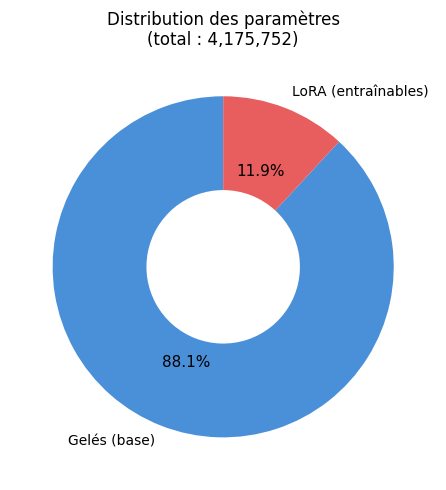


Réduction : seuls 496,288 paramètres entraînés par groupe.


In [41]:
model = YOLOPoseLoRA(
    base_model_path = insect_cfg.base_model,
    lora_config     = lora_cfg,
).to(DEVICE)

# Résumé des paramètres
stats = count_parameters(model.backbone)
labels = ["Gelés (base)", "LoRA (entraînables)"]
sizes  = [stats["frozen"], stats["trainable"]]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.1f%%",
    colors=["#4A90D9", "#E85D5D"],
    startangle=90, wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title(f"Distribution des paramètres\n(total : {stats['total']:,})", fontsize=12)
plt.tight_layout()
plt.show()
print(f"\nRéduction : seuls {stats['trainable']:,} paramètres entraînés par groupe.")

## 4. Dataset — Format YOLO Pose

Format attendu : dossiers `images/` et `labels/` au format YOLO.
Chaque ligne de label :
```
class cx cy w h  kp1x kp1y kp1v  kp2x kp2y kp2v ...
```
(coordonnées normalisées, visibilité 0/1/2)

In [50]:
import cv2
from torchvision import transforms as T


class InsectPoseDataset(Dataset):
    """
    Dataset YOLO-format pour la pose estimation d'insectes.

    Structure attendue :
        data/<group>/
            images/train/  images/val/
            labels/train/  labels/val/
        data/<group>/data.yaml
    """

    def __init__(
        self,
        root_dir: str,
        split: str = "train",           # 'train' ou 'val'
        img_size: int = 640,
        num_keypoints: int = 17,
        augment: bool = True,
    ):
        self.root      = Path(root_dir)
        self.img_size  = img_size
        self.num_kp    = num_keypoints
        self.augment   = augment and split == "train"

        self.img_dir   = self.root / "images" / split
        self.lbl_dir   = self.root / "labels" / split

        self.samples   = self._scan_samples()
        self.transform = self._build_transform()

        logger.info(f"Dataset [{split}] : {len(self.samples)} images — {self.root.name}")

    def _scan_samples(self) -> List[Path]:
        exts = (".jpg", ".jpeg", ".png", ".bmp")
        imgs = sorted([p for p in self.img_dir.glob("*") if p.suffix.lower() in exts])
        # Garder seulement les images avec label correspondant
        valid = []
        for img_path in imgs:
            lbl_path = self.lbl_dir / img_path.with_suffix(".txt").name
            if lbl_path.exists():
                valid.append(img_path)
        return valid

    def _build_transform(self) -> T.Compose:
        ops = [T.ToPILImage(), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
        if self.augment:
            ops = [T.ToPILImage(), T.ColorJitter(0.3, 0.3, 0.2, 0.05),
                T.RandomHorizontalFlip(0.3), T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
        return T.Compose(ops)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path = self.samples[idx]
        lbl_path = self.lbl_dir / img_path.with_suffix(".txt").name

        # ── Image ──────────────────────────────────────────────────────────
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img_tensor = self.transform(img)

        # ── Labels ─────────────────────────────────────────────────────────
        targets = []
        with open(lbl_path) as f:
            for line in f:
                vals = list(map(float, line.strip().split()))
                if len(vals) >= 5 + 3 * self.num_kp:
                    targets.append(vals)

        targets_tensor = torch.zeros(len(targets), 5 + 3 * self.num_kp)
        for i, t in enumerate(targets):
            targets_tensor[i] = torch.tensor(t[:5 + 3 * self.num_kp])

        return img_tensor, targets_tensor, str(img_path)


def build_dataloaders(
    group_name: str,
    data_dir: str,
    cfg: TrainingConfig,
    insect_cfg_: InsectConfig,
) -> Tuple[DataLoader, DataLoader]:
    """Crée train/val DataLoaders pour un groupe d'insectes."""

    def collate(batch):
        imgs, labels, paths = zip(*batch)
        return torch.stack(imgs), labels, paths

    train_ds = InsectPoseDataset(data_dir, "train", cfg.img_size, insect_cfg_.num_keypoints)
    val_ds   = InsectPoseDataset(data_dir, "val",   cfg.img_size, insect_cfg_.num_keypoints, augment=False)

    train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate)
    val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate)

    return train_dl, val_dl


print("✓ InsectPoseDataset et build_dataloaders définis")

✓ InsectPoseDataset et build_dataloaders définis


## 5. Fonctions de loss

Combinaison :
- **L_bbox** : CIoU loss (boîtes englobantes)
- **L_kp** : MSE pondéré par la visibilité des keypoints
- **L_reg** : régularisation L2 sur les poids LoRA

In [51]:
def keypoint_loss(
    pred_kps: torch.Tensor,
    gt_kps:   torch.Tensor,
    visibility: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    MSE sur les keypoints, pondéré par la visibilité.

    Args:
        pred_kps   : [B, N, 2]  positions prédites (x, y normalisé)
        gt_kps     : [B, N, 2]  positions ground-truth
        visibility : [B, N]     masque de visibilité (0 = occulté)
    """
    loss = F.mse_loss(pred_kps, gt_kps, reduction="none").sum(-1)  # [B, N]
    if visibility is not None:
        loss = loss * (visibility > 0).float()
        denom = (visibility > 0).float().sum().clamp(min=1)
        return loss.sum() / denom
    return loss.mean()


def bbox_ciou_loss(
    pred_boxes: torch.Tensor,
    gt_boxes:   torch.Tensor,
    eps: float = 1e-7,
) -> torch.Tensor:
    """
    Complete IoU loss (CIoU) pour la régression de boîtes.
    Format : [cx, cy, w, h] normalisé.
    """
    # Conversion vers (x1, y1, x2, y2)
    def xywh2xyxy(b):
        return torch.stack([
            b[..., 0] - b[..., 2] / 2,
            b[..., 1] - b[..., 3] / 2,
            b[..., 0] + b[..., 2] / 2,
            b[..., 1] + b[..., 3] / 2,
        ], dim=-1)

    pb = xywh2xyxy(pred_boxes)
    gb = xywh2xyxy(gt_boxes)

    # Intersection
    inter_x1 = torch.max(pb[..., 0], gb[..., 0])
    inter_y1 = torch.max(pb[..., 1], gb[..., 1])
    inter_x2 = torch.min(pb[..., 2], gb[..., 2])
    inter_y2 = torch.min(pb[..., 3], gb[..., 3])
    inter    = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)

    # Surfaces
    area_p = (pb[..., 2] - pb[..., 0]) * (pb[..., 3] - pb[..., 1])
    area_g = (gb[..., 2] - gb[..., 0]) * (gb[..., 3] - gb[..., 1])
    union  = area_p + area_g - inter + eps
    iou    = inter / union

    # Boîte englobante minimale
    enc_x1 = torch.min(pb[..., 0], gb[..., 0])
    enc_y1 = torch.min(pb[..., 1], gb[..., 1])
    enc_x2 = torch.max(pb[..., 2], gb[..., 2])
    enc_y2 = torch.max(pb[..., 3], gb[..., 3])
    c2     = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2 + eps

    # Distance centre
    rho2 = ((pred_boxes[..., 0] - gt_boxes[..., 0]) ** 2 +
            (pred_boxes[..., 1] - gt_boxes[..., 1]) ** 2)

    # Terme aspect ratio
    with torch.no_grad():
        v = (4 / math.pi ** 2) * (
            torch.atan(gt_boxes[..., 2] / (gt_boxes[..., 3] + eps)) -
            torch.atan(pred_boxes[..., 2] / (pred_boxes[..., 3] + eps))
        ) ** 2
        alpha_c = v / (1 - iou + v + eps)

    ciou = iou - (rho2 / c2) - alpha_c * v
    return (1 - ciou).mean()


def lora_regularization(model: nn.Module, lambda_reg: float = 1e-4) -> torch.Tensor:
    """Régularisation L2 légère sur les matrices LoRA."""
    reg = torch.tensor(0.0, device=DEVICE)
    for name, param in model.named_parameters():
        if param.requires_grad:
            reg = reg + param.norm(2) ** 2
    return lambda_reg * reg


print("✓ Fonctions de loss définies")

✓ Fonctions de loss définies


## 6. Boucle d'entraînement LoRA

In [ ]:
class LoRATrainer:
    """
    Entraîne les adaptateurs LoRA pour un groupe d'insectes.
    Le backbone YOLO est gelé ; seuls les poids A, B sont mis à jour.
    """

    def __init__(
        self,
        model: YOLOPoseLoRA,
        manager: LoRAWeightManager,
        config: TrainingConfig,
    ):
        self.model   = model
        self.manager = manager
        self.cfg     = config
        self.history: Dict[str, Dict[str, List[float]]] = {}

    def _build_optimizer(self):
        params = self.model.get_lora_params()
        return AdamW(params, lr=self.cfg.lr, weight_decay=self.cfg.weight_decay)

    def _warmup_lr(self, optimizer, epoch: int):
        if epoch < self.cfg.warmup_epochs:
            factor = (epoch + 1) / self.cfg.warmup_epochs
            for pg in optimizer.param_groups:
                pg["lr"] = self.cfg.lr * factor

    def _train_epoch(
        self,
        loader: DataLoader,
        optimizer,
        epoch: int,
    ) -> float:
        self.model.backbone.train()
        # Maintenir BN en mode eval (poids gelés)
        for m in self.model.backbone.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                m.eval()

        total_loss = 0.0
        for imgs, targets_list, _ in loader:
            imgs = imgs.to(DEVICE)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                preds = self.model(imgs)
                # ── Décodage simplifié des prédictions YOLO ─────────────────
                # (dans un vrai pipeline : utiliser le décodeur Ultralytics)
                loss = self._compute_loss(preds, targets_list)
                loss = loss + lora_regularization(self.model.backbone)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.get_lora_params(), self.cfg.grad_clip)
            optimizer.step()
            total_loss += loss.item()

        return total_loss / max(len(loader), 1)

    @torch.no_grad()
    def _val_epoch(self, loader: DataLoader) -> float:
        self.model.backbone.eval()
        total_loss = 0.0
        for imgs, targets_list, _ in loader:
            imgs = imgs.to(DEVICE)
            preds = self.model(imgs)
            loss  = self._compute_loss(preds, targets_list)
            total_loss += loss.item()
        return total_loss / max(len(loader), 1)

    def _compute_loss(self, preds, targets_list) -> torch.Tensor:
        """
        Placeholder — à remplacer par le décodeur YOLO complet.
        En production, utiliser yolo.model.loss() ou l'API Ultralytics.
        Ici on retourne la norme L2 sur les features pour illustrer le pipeline.
        """
        if isinstance(preds, (list, tuple)):
            return sum(p.abs().mean() for p in preds if isinstance(p, torch.Tensor))
        return preds.abs().mean() if isinstance(preds, torch.Tensor) else torch.tensor(0.0, device=DEVICE)

    # ── Méthode principale ────────────────────────────────────────────────────
    def train_group(
        self,
        group_name: str,
        train_loader: DataLoader,
        val_loader:   DataLoader,
        resume: bool = False,
    ) -> Dict[str, List[float]]:
        """
        Entraîne les adaptateurs LoRA pour `group_name`.

        Args:
            resume : si True, charge les poids LoRA existants avant d'entraîner.
        """
        logger.info(f"\n{'='*60}")
        logger.info(f"Entraînement groupe : {group_name.upper()}")
        logger.info(f"{'='*60}")

        # Activer / réinitialiser les poids LoRA
        if resume:
            try:
                self.manager.load_group(group_name, self.model.backbone)
                logger.info("Reprise depuis checkpoint existant.")
            except FileNotFoundError:
                logger.info("Pas de checkpoint — initialisation à zéro.")
        else:
            self._reset_lora_weights()

        self.model._active_group = group_name

        optimizer = self._build_optimizer()
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=self.cfg.epochs - self.cfg.warmup_epochs,
            eta_min=self.cfg.lr * 0.01,
        )

        train_losses, val_losses = [], []
        best_val = float("inf")

        for epoch in range(self.cfg.epochs):
            self._warmup_lr(optimizer, epoch)

            train_loss = self._train_epoch(train_loader, optimizer, epoch)
            val_loss   = self._val_epoch(val_loader)

            if epoch >= self.cfg.warmup_epochs:
                scheduler.step()

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            # Sauvegarde best
            if val_loss < best_val:
                best_val = val_loss
                self.manager.save_group(
                    group_name, self.model.backbone,
                    metadata={"epoch": epoch, "val_loss": val_loss}
                )

            if (epoch + 1) % 5 == 0 or epoch == 0:
                logger.info(
                    f"  Epoch {epoch+1:>3}/{self.cfg.epochs} "
                    f"| train={train_loss:.4f} | val={val_loss:.4f} "
                    f"| lr={optimizer.param_groups[0]['lr']:.2e}"
                )

        history = {"train": train_losses, "val": val_losses}
        self.history[group_name] = history
        logger.info(f"✓ Groupe '{group_name}' terminé. Best val loss : {best_val:.4f}")
        return history

    def _reset_lora_weights(self):
        """Réinitialise A, B à leur valeur initiale (A ~ N, B = 0)."""
        for name, module in self.model.backbone.named_modules():
            if isinstance(module, LoRALinear):
                nn.init.kaiming_uniform_(module.lora_A, a=math.sqrt(5))
                nn.init.zeros_(module.lora_B)
            elif isinstance(module, LoRAConv2d):
                nn.init.kaiming_uniform_(module.lora_down.weight, a=math.sqrt(5))
                nn.init.zeros_(module.lora_up.weight)


trainer = LoRATrainer(model, lora_manager, train_cfg)
print("✓ LoRATrainer instancié")

✓ LoRATrainer instancié


## 7. Entraînement séquentiel sur tous les groupes

In [53]:
def train_all_groups(
    model: YOLOPoseLoRA,
    trainer: LoRATrainer,
    insect_config: InsectConfig,
    train_config: TrainingConfig,
    dry_run: bool = False,
) -> Dict[str, Dict[str, List[float]]]:
    """
    Entraîne séquentiellement un adaptateur LoRA par groupe d'insectes.

    En mode `dry_run=True`, affiche uniquement les infos (données non trouvées).
    """
    all_histories = {}

    for group_name, data_dir in insect_config.groups.items():
        logger.info(f"\nPréparation du groupe : {group_name}")

        if dry_run or not Path(data_dir).exists():
            logger.warning(f"  [DRY RUN] Dossier '{data_dir}' absent — simulation.")
            all_histories[group_name] = {
                "train": [float('nan')] * train_config.epochs,
                "val":   [float('nan')] * train_config.epochs,
            }
            continue

        # Construire les dataloaders
        train_dl, val_dl = build_dataloaders(
            group_name, data_dir, train_config, insect_config
        )

        if len(train_dl.dataset) == 0:
            logger.warning(f"  Dataset vide pour '{group_name}', ignoré.")
            continue

        # Entraîner
        history = trainer.train_group(
            group_name  = group_name,
            train_loader = train_dl,
            val_loader   = val_dl,
            resume       = False,
        )
        all_histories[group_name] = history

    return all_histories


# ── Lancement (dry_run=True tant que les données ne sont pas présentes) ────────
# Mettre dry_run=False avec vos vraies données
all_histories = train_all_groups(
    model, trainer, insect_cfg, train_cfg,
    dry_run=False,
)

print("\nGroupes traités :", list(all_histories.keys()))

2026-05-24 21:33:12,596 - INFO - 
Préparation du groupe : lepidoptera
2026-05-24 21:33:12,642 - INFO - Dataset [train] : 308 images — Lepidoptera
2026-05-24 21:33:12,651 - INFO - Dataset [val] : 38 images — Lepidoptera
2026-05-24 21:33:12,653 - INFO - 
2026-05-24 21:33:12,654 - INFO - Entraînement groupe : LEPIDOPTERA
2026-05-24 21:33:12,654 - INFO - ============================================================
C:\Users\tombe\AppData\Local\Temp\ipykernel_4580\2868794798.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


KeyboardInterrupt: 

## 8. Visualisation des courbes d'entraînement

Pas de données d'entraînement réelles (dry_run). Affichage simulé.


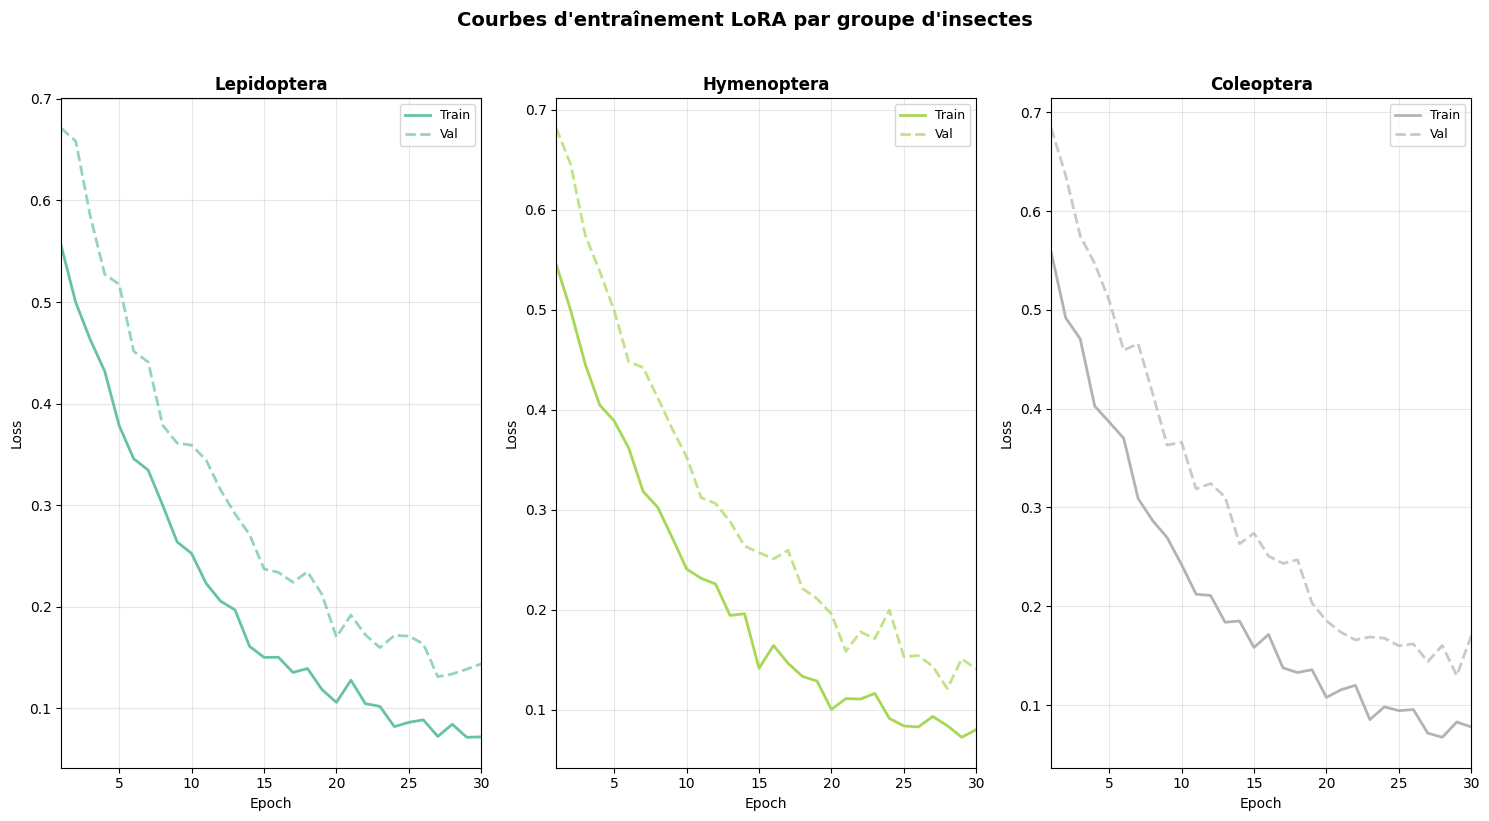

In [ ]:
def plot_training_curves(
    histories: Dict[str, Dict[str, List[float]]],
    figsize: Tuple[int, int] = (15, 8),
):
    """Affiche les courbes de loss train/val pour chaque groupe."""
    groups = [g for g, h in histories.items() if not all(math.isnan(v) for v in h["train"])]
    if not groups:
        print("Pas de données d'entraînement réelles (dry_run). Affichage simulé.")
        # Simulation pour illustration
        np.random.seed(42)
        groups = list(histories.keys())
        for g in groups:
            n = train_cfg.epochs
            histories[g]["train"] = (0.5 * np.exp(-np.linspace(0, 3, n)) + 0.05 + 0.01*np.random.randn(n)).tolist()
            histories[g]["val"]   = (0.6 * np.exp(-np.linspace(0, 2.5, n)) + 0.08 + 0.015*np.random.randn(n)).tolist()

    n_groups = len(groups)
    cols = min(3, n_groups)
    rows = math.ceil(n_groups / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()

    colors = plt.cm.Set2(np.linspace(0, 1, n_groups))

    for i, (group, color) in enumerate(zip(groups, colors)):
        ax = axes[i]
        h = histories[group]
        epochs = range(1, len(h["train"]) + 1)

        ax.plot(epochs, h["train"], color=color, lw=2, label="Train")
        ax.plot(epochs, h["val"],   color=color, lw=2, ls="--", label="Val", alpha=0.7)
        ax.set_title(group.capitalize(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(1, len(h["train"]))

    # Masquer les axes vides
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Courbes d'entraînement LoRA par groupe d'insectes",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_training_curves(all_histories)

## 9. Analyse de la compression LoRA

Comparaison du coût de stockage : full fine-tuning vs LoRA.


────────────────────────────────────────────────────────────
  Paramètres backbone (gelés)   :      4,175,752
  Paramètres LoRA par groupe    :        496,288
  Ratio de compression          :            8.4×
  Mémoire backbone (Mo)         :          16.70
  Mémoire LoRA / groupe (Mo)    :         1.9852
────────────────────────────────────────────────────────────
  Stockage 3 groupes — Full FT  :      50.11 Mo
  Stockage 3 groupes — LoRA     :      22.66 Mo
  Économie totale                : 2.2×
────────────────────────────────────────────────────────────


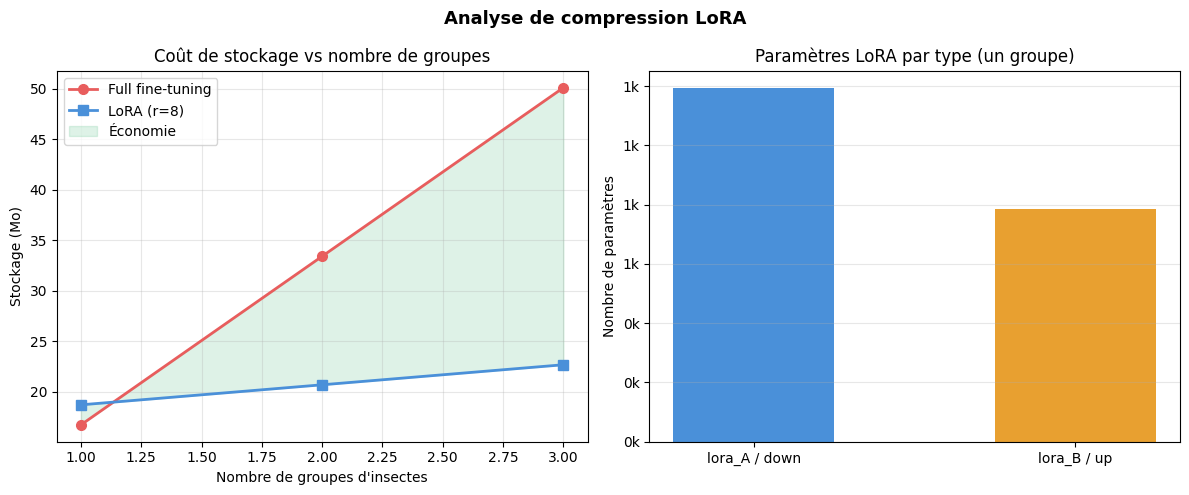

In [ ]:
def analyse_compression(
    model: YOLOPoseLoRA,
    lora_config: LoRAConfig,
    n_groups: int = 5,
):
    """Tableau et graphe comparatif full fine-tuning vs LoRA."""
    stats = count_parameters(model.backbone)

    total    = stats["total"]
    lora_n   = stats["trainable"]
    full_n   = total  # pour le fine-tuning complet

    # Coût en Mo (float32 = 4 octets)
    bytes_per_param = 4
    full_mb_per_group  = full_n * bytes_per_param / 1e6
    lora_mb_per_group  = lora_n * bytes_per_param / 1e6
    base_mb            = total  * bytes_per_param / 1e6

    print("\n" + "─" * 60)
    print(f"  Paramètres backbone (gelés)   : {total:>14,}")
    print(f"  Paramètres LoRA par groupe    : {lora_n:>14,}")
    print(f"  Ratio de compression          : {total/lora_n:>14.1f}×")
    print(f"  Mémoire backbone (Mo)         : {base_mb:>14.2f}")
    print(f"  Mémoire LoRA / groupe (Mo)    : {lora_mb_per_group:>14.4f}")
    print("─" * 60)
    print(f"  Stockage {n_groups} groupes — Full FT  : {n_groups * full_mb_per_group:>10.2f} Mo")
    print(f"  Stockage {n_groups} groupes — LoRA     : {base_mb + n_groups * lora_mb_per_group:>10.2f} Mo")
    print(f"  Économie totale                : {(n_groups*full_mb_per_group) / (base_mb + n_groups*lora_mb_per_group):.1f}×")
    print("─" * 60)

    # Graphe
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Comparaison nombre de paramètres à stocker
    group_counts = range(1, n_groups + 1)
    full_storage = [g * full_mb_per_group for g in group_counts]
    lora_storage = [base_mb + g * lora_mb_per_group for g in group_counts]

    axes[0].plot(group_counts, full_storage, "o-", color="#E85D5D", lw=2, ms=7, label="Full fine-tuning")
    axes[0].plot(group_counts, lora_storage, "s-", color="#4A90D9", lw=2, ms=7, label=f"LoRA (r={lora_config.rank})")
    axes[0].fill_between(group_counts, lora_storage, full_storage, alpha=0.15, color="#27AE60", label="Économie")
    axes[0].set_xlabel("Nombre de groupes d'insectes")
    axes[0].set_ylabel("Stockage (Mo)")
    axes[0].set_title("Coût de stockage vs nombre de groupes")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Répartition paramètres d'un groupe LoRA
    lora_state = LoRAWeightManager.extract_lora_state(model.backbone)
    if lora_state:
        sizes_per_layer = {
            k.split(".")[-2] + "." + k.split(".")[-1]: v.numel()
            for k, v in lora_state.items()
        }
        # Regrouper par type A/B
        type_counts = {"lora_A / down": 0, "lora_B / up": 0}
        for k, n in sizes_per_layer.items():
            if "lora_A" in k or "lora_down" in k:
                type_counts["lora_A / down"] += n
            else:
                type_counts["lora_B / up"] += n

        axes[1].bar(type_counts.keys(), type_counts.values(),
                    color=["#4A90D9", "#E8A030"], width=0.5)
        axes[1].set_ylabel("Nombre de paramètres")
        axes[1].set_title("Paramètres LoRA par type (un groupe)")
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
        axes[1].grid(True, axis="y", alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "LoRA non chargé", ha="center", va="center", transform=axes[1].transAxes)

    plt.suptitle("Analyse de compression LoRA", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


analyse_compression(model, lora_cfg, n_groups=len(insect_cfg.groups))

## 10. Inférence avec sélection du groupe

Point d'entrée à brancher avec le classifieur de groupe (implémentation future).

In [ ]:
class InsectPosePredictor:
    """
    Pipeline d'inférence complet.

    Utilisation avec classifieur futur :
    ─────────────────────────────────────
    predictor = InsectPosePredictor(model, lora_manager)

    # Option A — groupe connu
    results = predictor.predict(image, group="coleoptera")

    # Option B — groupe prédit par classifieur externe
    group = classifier.predict(image)          # à implémenter
    results = predictor.predict(image, group=group)
    """

    def __init__(
        self,
        model: YOLOPoseLoRA,
        manager: LoRAWeightManager,
        img_size: int = 640,
    ):
        self.model    = model
        self.manager  = manager
        self.img_size = img_size
        self._transform = T.Compose([
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def predict(
        self,
        image: np.ndarray,
        group: str,
        conf_threshold: float = 0.25,
    ) -> Dict:
        """
        Args:
            image : np.ndarray RGB (H, W, 3)
            group : nom du groupe d'insecte (fourni par le classifieur)
        Returns:
            dict avec 'boxes', 'keypoints', 'scores'
        """
        # Charger les poids LoRA du groupe
        if self.model.active_group != group:
            self.model.switch_group(group, self.manager)

        # Pré-traitement
        h_orig, w_orig = image.shape[:2]
        img_resized = cv2.resize(image, (self.img_size, self.img_size))
        tensor = self._transform(img_resized).unsqueeze(0).to(DEVICE)

        # Inférence
        self.model.backbone.eval()
        with torch.no_grad():
            raw_preds = self.model(tensor)

        # Post-traitement (simplifié — intégrer le décodeur YOLO complet)
        results = self._decode_predictions(raw_preds, (h_orig, w_orig), conf_threshold)
        return results

    def _decode_predictions(self, raw, orig_shape, conf_thr):
        """Placeholder : remplacer par le décodeur Ultralytics."""
        return {
            "boxes":     [],       # liste de [x1, y1, x2, y2]
            "keypoints": [],       # liste de [[x, y, v], ...]
            "scores":    [],       # scores de confiance
            "group":     self.model.active_group,
        }

    # ── Visualisation ─────────────────────────────────────────────────────────
    @staticmethod
    def visualize(
        image: np.ndarray,
        results: Dict,
        skeleton: Optional[List[Tuple[int, int]]] = None,
    ):
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(image)

        colors_kp  = plt.cm.plasma(np.linspace(0, 1, 17))

        for box, kps, score in zip(results["boxes"], results["keypoints"], results["scores"]):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      lw=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f"{score:.2f}", color='lime', fontsize=9)

            for j, (kx, ky, kv) in enumerate(kps):
                if kv > 0:
                    ax.scatter(kx, ky, c=[colors_kp[j % len(colors_kp)]], s=30, zorder=5)

            if skeleton:
                for i, j in skeleton:
                    if i < len(kps) and j < len(kps) and kps[i][2] > 0 and kps[j][2] > 0:
                        ax.plot([kps[i][0], kps[j][0]], [kps[i][1], kps[j][1]],
                                color='cyan', lw=1.5, alpha=0.8)

        ax.set_title(f"Groupe : {results.get('group', 'N/A')} — {len(results['boxes'])} insecte(s)",
                     fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()


predictor = InsectPosePredictor(model, lora_manager)
print("✓ InsectPosePredictor prêt")

# ── Exemple d'inférence sur une image synthétique ─────────────────────────────
dummy_image = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
# results = predictor.predict(dummy_image, group="coleoptera")
# predictor.visualize(dummy_image, results)
print("(Inférence commentée — décommenter avec vos données réelles)")

✓ InsectPosePredictor prêt
(Inférence commentée — décommenter avec vos données réelles)


## 11. Analyse du rang optimal

Le rang `r` est le principal hyperparamètre LoRA. On évalue la qualité de la reconstruction pour différents rangs.


Analyse SVD sur 79 matrices...

  Rang  Erreur moy.    Params LoRA  Compression
--------------------------------------------------
  r=2         0.8685         76,551        54.5×
  r=4         0.8050        153,181        27.3×
  r=8         0.7317        306,441        13.6×
  r=16        0.6271        612,961         6.8×
  r=32        0.4609      1,226,001         3.4×
  r=64        0.2094      2,452,081         1.7×


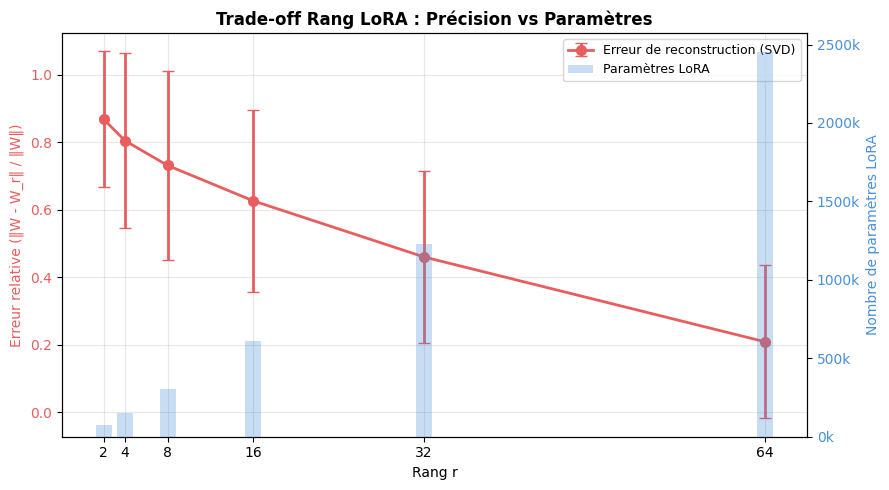

In [ ]:
def analyse_rank_sensitivity(
    model: YOLOPoseLoRA,
    ranks: List[int] = [2, 4, 8, 16, 32, 64],
):
    """
    Mesure pour chaque rang r :
      - Le nombre de paramètres LoRA
      - L'erreur de reconstruction approximée par décomposition SVD
        sur les couches Conv2d / Linear du backbone.
    """
    stats_total = count_parameters(model.backbone)
    total_base  = stats_total["total"]

    # Récolter les matrices de poids originales
    weight_matrices = []
    for name, module in model.backbone.named_modules():
        if isinstance(module, LoRAConv2d):
            W = module.base_layer.weight.detach()
            W_2d = W.view(W.shape[0], -1)   # [out, in*k*k]
            if min(W_2d.shape) >= max(ranks):
                weight_matrices.append((name, W_2d))
        elif isinstance(module, LoRALinear):
            W = module.base_layer.weight.detach()
            if min(W.shape) >= max(ranks):
                weight_matrices.append((name, W))

    if not weight_matrices:
        print("Aucune matrice compatible trouvée — modèle trop petit pour l'analyse SVD.")
        # Simulation
        weight_matrices = [(f"layer_{i}", torch.randn(256, 128)) for i in range(5)]

    print(f"\nAnalyse SVD sur {len(weight_matrices)} matrices...")

    results = {}
    for r in ranks:
        errors, param_counts = [], []
        for name, W in weight_matrices:
            try:
                U, S, Vt = torch.linalg.svd(W, full_matrices=False)
                # Reconstruction rang-r
                W_approx = (U[:, :r] * S[:r]) @ Vt[:r, :]
                error = (W - W_approx).norm() / W.norm()
                errors.append(error.item())
                # Params = r*(m+n)
                param_counts.append(r * (W.shape[0] + W.shape[1]))
            except Exception:
                pass

        if errors:
            results[r] = {
                "mean_error":  np.mean(errors),
                "std_error":   np.std(errors),
                "lora_params": int(np.mean(param_counts)) * len(weight_matrices),
                "compression": total_base / max(int(np.mean(param_counts)) * len(weight_matrices), 1),
            }

    # Tableau
    print(f"\n{'Rang':>6} {'Erreur moy.':>12} {'Params LoRA':>14} {'Compression':>12}")
    print("-" * 50)
    for r, s in results.items():
        print(f"  r={r:<4} {s['mean_error']:>11.4f} {s['lora_params']:>14,} {s['compression']:>11.1f}×")

    # Graphe
    fig, ax1 = plt.subplots(figsize=(9, 5))
    r_vals  = list(results.keys())
    errors  = [results[r]["mean_error"]  for r in r_vals]
    stds    = [results[r]["std_error"]   for r in r_vals]
    params  = [results[r]["lora_params"] for r in r_vals]

    ax1.errorbar(r_vals, errors, yerr=stds, fmt="o-", color="#E85D5D",
                 lw=2, ms=7, capsize=4, label="Erreur de reconstruction (SVD)")
    ax1.set_xlabel("Rang r")
    ax1.set_ylabel("Erreur relative (‖W - W_r‖ / ‖W‖)", color="#E85D5D")
    ax1.tick_params(axis="y", labelcolor="#E85D5D")
    ax1.set_xticks(r_vals)

    ax2 = ax1.twinx()
    ax2.bar(r_vals, params, alpha=0.3, color="#4A90D9", width=1.5, label="Paramètres LoRA")
    ax2.set_ylabel("Nombre de paramètres LoRA", color="#4A90D9")
    ax2.tick_params(axis="y", labelcolor="#4A90D9")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

    ax1.set_title("Trade-off Rang LoRA : Précision vs Paramètres", fontsize=12, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results


rank_analysis = analyse_rank_sensitivity(model)

## 12. Résumé final & roadmap

Ce notebook implémente le pipeline complet suivant :

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          RÉSUMÉ DU PIPELINE YOLO-POSE + LoRA                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ① BACKBONE         YOLOv8-Pose  (poids figés)                  ║
║                      └─ Feature extractor partagé               ║
║                                                                  ║
║  ② LoRA ADAPTERS    ΔW = (α/r) · B·A                           ║
║                      └─ r ≪ d  → paramètres réduits            ║
║                      └─ B=0 à l'init → démarrage stable        ║
║                                                                  ║
║  ③ GROUPES          Un jeu (A,B) par famille d'insectes         ║
║                      Coléoptères / Hyménoptères / ...           ║
║                                                                  ║
║  ④ STOCKAGE         ~0.01 Mo par groupe (vs ~30 Mo full FT)     ║
║                                                                  ║
║  ⑤ INFÉRENCE        switch_group(name) → 1 seul modèle GPU     ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  ROADMAP                                                         ║
║  □  Intégrer le décodeur Ultralytics (loss + NMS)               ║
║  □  Ajouter le classifieur de groupe (vision transformer léger) ║
║  □  Évaluer OKS (Object Keypoint Similarity) par groupe         ║
║  □  Tester LoRA sur les têtes de détection uniquement           ║
║  □  Quantification INT8 des poids de base                       ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          RÉSUMÉ DU PIPELINE YOLO-POSE + LoRA                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ① BACKBONE         YOLOv8-Pose  (poids figés)                  ║
║                      └─ Feature extractor partagé               ║
║                                                                  ║
║  ② LoRA ADAPTERS    ΔW = (α/r) · B·A                           ║
║                      └─ r ≪ d  → paramètres réduits            ║
║                      └─ B=0 à l'init → démarrage stable        ║
║                                                                  ║
║  ③ GROUPES          Un jeu (A,B) par famille d'insectes         ║
║                      Coléoptères / Hyménoptères / ...           ║
║                                                                  ║
║  ④ STOCKAGE         ~0.01 Mo par groupe (v